In [42]:
import joblib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [43]:
# 1. Load the engineered data
df = pd.read_csv('../data/processed/features_engineered.csv')

In [44]:
# 2. Select numerical features that define a user's physical state and habits
cluster_features = [
    'Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 
    'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Caffeine_per_Cup'
]

X = df[cluster_features].copy()

In [45]:
# 3. Standardize the data 
# (K-Means uses distance, so we must ensure Caffeine_mg doesn't overpower Sleep_Hours)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✓ Data loaded and scaled. Shape: {X_scaled.shape}")

✓ Data loaded and scaled. Shape: (10000, 8)


In [46]:
wcss = [] # Within-Cluster Sum of Squares (how tight the clusters are)
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

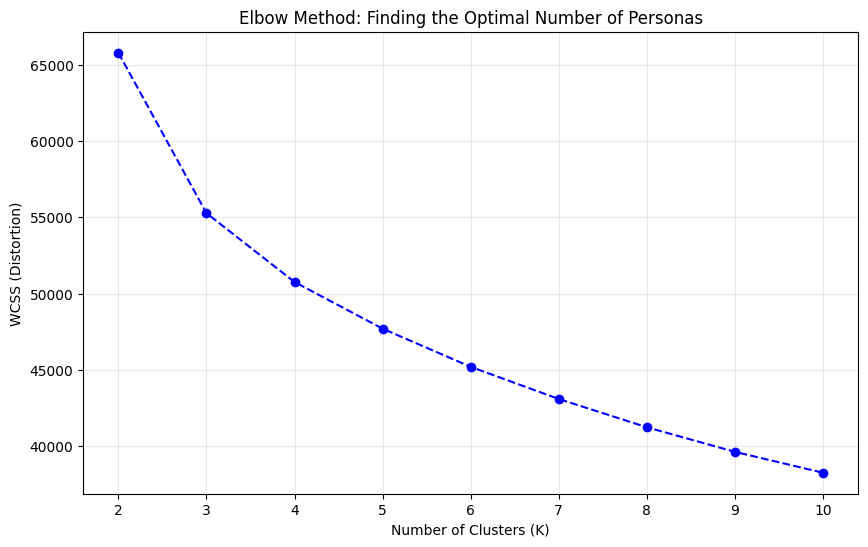

In [47]:
# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method: Finding the Optimal Number of Personas')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Distortion)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
# 1. Fit the final K-Means model with 4 clusters
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Add the predicted cluster labels (0, 1, 2, or 3) directly into our main dataframe
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [49]:
# 2. Use PCA to reduce our 8 features down to 2 dimensions for plotting
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

df['PCA1'] = pca_features[:, 0]
df['PCA2'] = pca_features[:, 1]

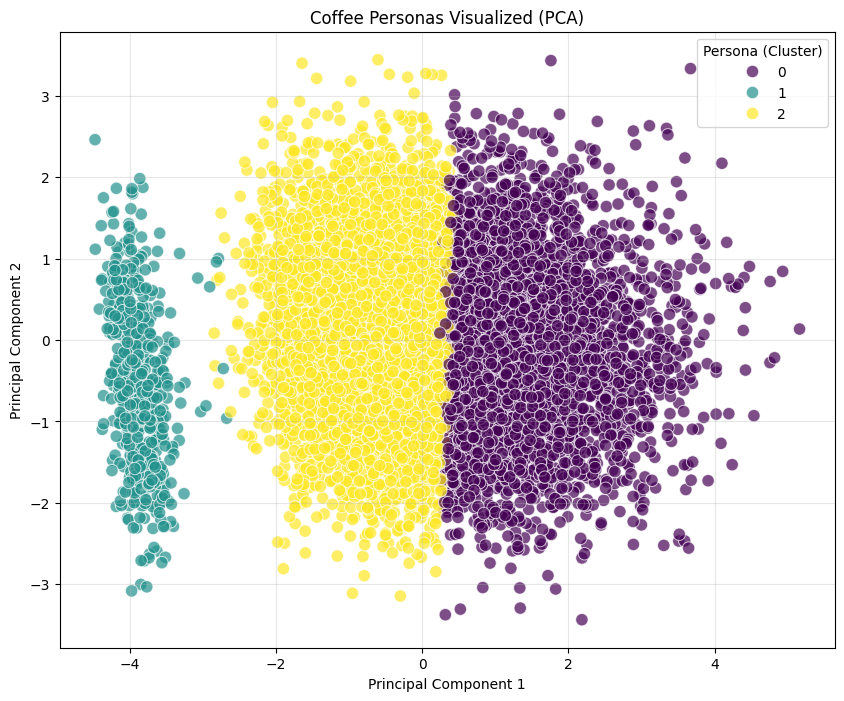

In [50]:
# 3. Plot the clusters!
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Cluster', 
    data=df, 
    palette='viridis', 
    alpha=0.7, 
    s=80 # dot size
)
plt.title('Coffee Personas Visualized (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Persona (Cluster)')
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
# Calculate the average values for our original features, grouped by Cluster
cluster_profile = df.groupby('Cluster')[cluster_features].mean()

# Display the table cleanly
display(cluster_profile.round(2))

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Caffeine_per_Cup
Cluster,,,,,,,,
0,34.62,3.85,365.72,6.21,23.86,71.69,7.52,95.01
1,34.74,0.00,0.19,6.98,23.87,69.42,7.43,0.71
2,35.24,1.69,160.72,6.95,24.10,69.88,7.47,95.10


In [52]:
# Now we look at the 'answer keys' to see how the Personas actually feel!
outcome_features = ['Sleep_Quality_Num', 'Stress_Level_Num', 'Health_Issues_Num']

outcomes_profile = df.groupby('Cluster')[outcome_features].mean()
display(outcomes_profile.round(2))

,Sleep_Quality_Num,Stress_Level_Num,Health_Issues_Num
Cluster,,,
0,1.48,0.58,0.57
1,1.92,0.29,0.37
2,1.93,0.26,0.37


In [53]:
# Create the models directory if it doesn't exist (though you likely have it from Week 6)
os.makedirs('../models/clustering', exist_ok=True)

# Save the StandardScaler (Crucial: we must use the exact same scaler for new users)
joblib.dump(scaler, '../models/clustering/cluster_scaler.joblib')

# Save the K-Means model
joblib.dump(kmeans, '../models/clustering/kmeans_model.joblib')

['../models/clustering/kmeans_model.joblib']